# Python GIS Procedural Pipeline

This notebook implements an end-to-end pipeline:
1. Draw a polygon on an interactive map
2. Extract GeoJSON & transform coordinates to UTM (CCW ordering)
3. Generate a procedural building with PyPRT (CityEngine)
4. Visualize the 3D model with Autodesk Viewer

## تثبيت المكتبات (Install Libraries)

If running outside the project venv, uncomment the following line:
```
# !pip install leafmap shapely pyproj pyprt pythreejs ipywidgets trimesh
```

---
## الخلية 1: إعداد الخريطة ورسم المضلع
## Cell 1: Interactive Map & Polygon Drawing

In [19]:
import leafmap

m = leafmap.Map(center=[15, 45], zoom=16)

# The draw tool is available by default in leafmap.
# Draw a polygon on the map below, then proceed to Cell 2.
m

Map(center=[15, 45], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_tex…

---
## الخلية 2: استخراج GeoJSON وتحويل الإحداثيات إلى UTM وترتيب CCW
## Cell 2: Extract GeoJSON → Transform to UTM → Ensure CCW Winding

إحداثيات Lat/Lon الأصلية (Original Lat/Lon coordinates):
[(45.001379, 15.00146), (45.001379, 15.001916), (45.001916, 15.001916), (45.001916, 15.00146), (45.001379, 15.00146)]

تم تحويل الإحداثيات إلى UTM وترتيبها CCW بنجاح
(Coordinates transformed to UTM and ordered CCW successfully)

UTM Coords (5 vertices):
  [0] x=500148.25, y=1658487.48
  [1] x=500205.98, y=1658487.48
  [2] x=500205.98, y=1658537.91
  [3] x=500148.25, y=1658537.91
  [4] x=500148.25, y=1658487.48


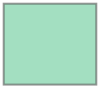

Map(center=[15, 45], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_tex…

In [20]:
from shapely.geometry import shape, Polygon
from pyproj import Transformer

if len(m.draw_features) == 0:
    raise RuntimeError("لم يتم رسم أي مضلع بعد — No polygon drawn yet. Run Cell 1 and draw a polygon first.")

# Take the most recently drawn feature
geojson_feature = m.draw_features[-1]
polygon = shape(geojson_feature['geometry'])
coords = list(polygon.exterior.coords)

print("إحداثيات Lat/Lon الأصلية (Original Lat/Lon coordinates):")
print(coords)

# Transform from WGS84 (EPSG:4326) to UTM Zone 38N (EPSG:32638)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32638", always_xy=True)
utm_coords = [transformer.transform(x, y) for x, y in coords]
utm_polygon = Polygon(utm_coords)

# Ensure counter-clockwise (CCW) winding order
if not utm_polygon.exterior.is_ccw:
    utm_coords = list(utm_polygon.exterior.coords)[::-1]
    utm_polygon = Polygon(utm_coords)

print("\nتم تحويل الإحداثيات إلى UTM وترتيبها CCW بنجاح")
print("(Coordinates transformed to UTM and ordered CCW successfully)")
print(f"\nUTM Coords ({len(utm_coords)} vertices):")
for i, c in enumerate(utm_coords):
    print(f"  [{i}] x={c[0]:.2f}, y={c[1]:.2f}")

from IPython.display import display
display(utm_polygon)  # Show the 2D polygon shape

# Create an interactive map for the extracted feature
m2 = leafmap.Map(center=[15, 45], zoom=16)
fc = {"type": "FeatureCollection", "features": [geojson_feature]}
m2.add_geojson(fc, layer_name="Extracted Polygon")
m2

---
## الخلية 3: إرسال الشكل إلى PyPRT وتوليد المبنى Procedural
## Cell 3: Send Shape to PyPRT & Generate Procedural Building

In [21]:
import pyprt, os, base64
import numpy as np

pyprt.initialize_prt()

# إخراج الإحداثيات للمبنى مع التوسيط (Centering) لضمان ظهوره في الفيوور
coords_2d = list(utm_polygon.exterior.coords)[:-1]

# حساب المركز (Centroid) لجعل الموديل حول نقطة الصفر (0,0,0)
center_x = sum(c[0] for c in coords_2d) / len(coords_2d)
center_y = sum(c[1] for c in coords_2d) / len(coords_2d)

flat_coords = []
for x, y in coords_2d:
    # طرح المركز لضمان التوسيط التام
    flat_coords.extend([x - center_x, 0.0, y - center_y])

initial_shape = pyprt.InitialShape(flat_coords)
attributes = {"Nbr_of_Floors": 12, "Usage": "Residential"}

RPK_PATH = r"C:\RPK\RuleFootprint.rpk"
model_generator = pyprt.ModelGenerator([initial_shape])

encoder = "com.esri.prt.codecs.GLTFEncoder"
out_dir = os.path.join(os.getcwd(), "output_models")
os.makedirs(out_dir, exist_ok=True)

encoder_options = {
    "outputPath": out_dir,
    "baseName": "procedural_building"
}

# توليد المبنى
model_generator.generate_model([attributes], RPK_PATH, encoder, encoder_options)

# قراءة الملف وتحويله لـ Base64
glb_path = os.path.join(out_dir, "procedural_building_0.glb")
with open(glb_path, "rb") as f:
    glb_data = f.read()

model_b64 = base64.b64encode(glb_data).decode('utf-8')

print(f"✅ Model Centered and Ready!")
print(f"Shifted by Central Offset: X={center_x:.2f}, Y={center_y:.2f}")


[PRT] [2026-03-12 08:30:17] [warning] CGB file contains warning 'Potentially problematic CGAC version 1.16 : major number smaller than current (2.10). Recompiling with current CGA Compiler is recommended.'
✅ Model Centered and Ready!
Shifted by Central Offset: X=500177.12, Y=1658512.69


---
## الخلية 4: عرض النموذج باستخدام Autodesk Viewer
## Cell 4: Visualize the Model with Autodesk Viewer

In [22]:
import os, webbrowser
from IPython.display import display, HTML

html_template = """<!DOCTYPE html>
<html>
<head>
    <title>CityEngine 3D Building Viewer</title>
    <meta charset="utf-8">
    <style>
        * { margin: 0; padding: 0; box-sizing: border-box; }
        body { overflow: hidden; background: #1a1a2e; font-family: 'Segoe UI', sans-serif; }
        canvas { display: block; }
        #toolbar {
            position: absolute; top: 15px; left: 15px; z-index: 10;
            display: flex; flex-direction: column; gap: 8px;
        }
        .btn {
            background: rgba(0,118,209,0.9); color: white; border: none;
            padding: 10px 18px; border-radius: 6px; cursor: pointer;
            font-weight: 600; font-size: 13px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.3);
        }
        .btn:hover { background: rgba(0,90,161,0.95); }
        .btn.gray { background: rgba(80,80,80,0.85); }
        #status {
            background: rgba(0,0,0,0.85); color: #0f0;
            padding: 10px 14px; border-radius: 6px;
            font-family: Consolas, monospace; font-size: 12px;
            min-width: 300px; border-left: 3px solid #0f0;
        }
        #info {
            position: absolute; bottom: 15px; left: 15px; z-index: 10;
            background: rgba(0,0,0,0.7); color: #aaa; padding: 8px 14px;
            border-radius: 6px; font-size: 11px; font-family: Consolas, monospace;
        }
    </style>
</head>
<body>
    <div id="toolbar">
        <div id="status">⏳ Loading Three.js...</div>
        <button class="btn" onclick="resetCamera()">🎯 Focus on Building</button>
        <button class="btn gray" onclick="toggleWireframe()">📐 Toggle Wireframe</button>
        <button class="btn gray" onclick="toggleAutoRotate()">🔄 Auto Rotate</button>
    </div>
    <div id="info">Mouse: Left=Rotate | Scroll=Zoom | Right=Pan</div>

    <script type="importmap">
    {
        "imports": {
            "three": "https://cdn.jsdelivr.net/npm/three@0.160.0/build/three.module.js",
            "three/addons/": "https://cdn.jsdelivr.net/npm/three@0.160.0/examples/jsm/"
        }
    }
    </script>

    <script type="module">
    import * as THREE from 'three';
    import { OrbitControls } from 'three/addons/controls/OrbitControls.js';
    import { GLTFLoader } from 'three/addons/loaders/GLTFLoader.js';

    const log = (m) => document.getElementById('status').innerHTML = m;
    let wireframeMode = false;
    let loadedModel = null;

    // Scene setup
    const scene = new THREE.Scene();
    scene.background = new THREE.Color(0x87CEEB); // Sky blue
    scene.fog = new THREE.Fog(0x87CEEB, 500, 2000);

    // Camera
    const camera = new THREE.PerspectiveCamera(45, window.innerWidth / window.innerHeight, 0.1, 5000);
    camera.position.set(150, 200, 250);

    // Renderer
    const renderer = new THREE.WebGLRenderer({ antialias: true });
    renderer.setSize(window.innerWidth, window.innerHeight);
    renderer.setPixelRatio(window.devicePixelRatio);
    renderer.shadowMap.enabled = true;
    renderer.shadowMap.type = THREE.PCFSoftShadowMap;
    renderer.toneMapping = THREE.ACESFilmicToneMapping;
    renderer.toneMappingExposure = 1.2;
    document.body.appendChild(renderer.domElement);

    // Controls
    const controls = new OrbitControls(camera, renderer.domElement);
    controls.enableDamping = true;
    controls.dampingFactor = 0.05;
    controls.target.set(0, -76, 0);

    // Lighting
    const ambientLight = new THREE.AmbientLight(0xffffff, 0.6);
    scene.add(ambientLight);

    const dirLight = new THREE.DirectionalLight(0xffffff, 1.2);
    dirLight.position.set(100, 200, 100);
    dirLight.castShadow = true;
    dirLight.shadow.mapSize.width = 2048;
    dirLight.shadow.mapSize.height = 2048;
    dirLight.shadow.camera.near = 0.5;
    dirLight.shadow.camera.far = 1000;
    dirLight.shadow.camera.left = -200;
    dirLight.shadow.camera.right = 200;
    dirLight.shadow.camera.top = 200;
    dirLight.shadow.camera.bottom = -200;
    scene.add(dirLight);

    const hemiLight = new THREE.HemisphereLight(0x87CEEB, 0x362D1B, 0.5);
    scene.add(hemiLight);

    // Ground plane
    const groundGeo = new THREE.PlaneGeometry(2000, 2000);
    const groundMat = new THREE.MeshStandardMaterial({ color: 0x4a7c59, roughness: 0.9 });
    const ground = new THREE.Mesh(groundGeo, groundMat);
    ground.rotation.x = -Math.PI / 2;
    ground.receiveShadow = true;
    scene.add(ground);

    // Grid helper
    const gridHelper = new THREE.GridHelper(500, 50, 0x888888, 0x444444);
    gridHelper.position.y = 0.1;
    scene.add(gridHelper);

    // Axes helper
    const axesHelper = new THREE.AxesHelper(50);
    scene.add(axesHelper);

    // Load GLB model
    log('📦 Decoding Base64 model data...');
    const b64 = "{{MODEL_B64}}";
    const binStr = atob(b64);
    const bytes = new Uint8Array(binStr.length);
    for (let i = 0; i < binStr.length; i++) bytes[i] = binStr.charCodeAt(i);
    const blob = new Blob([bytes.buffer], { type: 'model/gltf-binary' });
    const url = URL.createObjectURL(blob);

    log('🔧 Loading GLB with Three.js GLTFLoader...');
    const loader = new GLTFLoader();
    loader.load(url, (gltf) => {
        loadedModel = gltf.scene;
        
        // Enable shadows on all meshes
        loadedModel.traverse((child) => {
            if (child.isMesh) {
                child.castShadow = true;
                child.receiveShadow = true;
                if (child.material) {
                    child.material.side = THREE.DoubleSide;
                }
            }
        });
        
        scene.add(loadedModel);
        
        // Calculate bounding box for camera positioning
        const box = new THREE.Box3().setFromObject(loadedModel);
        const center = box.getCenter(new THREE.Vector3());
        const size = box.getSize(new THREE.Vector3());
        const maxDim = Math.max(size.x, size.y, size.z);
        
        // Position camera for nice isometric view
        camera.position.set(
            center.x + maxDim * 1.0,
            center.y + maxDim * 0.8,
            center.z + maxDim * 1.0
        );
        controls.target.copy(center);
        controls.update();
        
        // Adjust ground to bottom of building
        ground.position.y = box.min.y;
        gridHelper.position.y = box.min.y + 0.1;
        
        log('✅ <span style="color:#4caf50">Building Loaded!</span> ' +
            'Size: ' + size.x.toFixed(0) + 'x' + size.y.toFixed(0) + 'x' + size.z.toFixed(0) + 'm');
        
        URL.revokeObjectURL(url);
    }, (progress) => {
        if (progress.total > 0) {
            const pct = Math.round(progress.loaded / progress.total * 100);
            log('📦 Loading... ' + pct + '%');
        }
    }, (error) => {
        log('❌ Error: ' + error.message);
        console.error(error);
    });

    // Window resize
    window.addEventListener('resize', () => {
        camera.aspect = window.innerWidth / window.innerHeight;
        camera.updateProjectionMatrix();
        renderer.setSize(window.innerWidth, window.innerHeight);
    });

    // Animation loop
    function animate() {
        requestAnimationFrame(animate);
        controls.update();
        renderer.render(scene, camera);
    }
    animate();

    // Global functions for buttons
    window.resetCamera = () => {
        if (!loadedModel) return;
        const box = new THREE.Box3().setFromObject(loadedModel);
        const center = box.getCenter(new THREE.Vector3());
        const size = box.getSize(new THREE.Vector3());
        const maxDim = Math.max(size.x, size.y, size.z);
        camera.position.set(center.x + maxDim, center.y + maxDim * 0.7, center.z + maxDim);
        controls.target.copy(center);
        controls.update();
        log('🎯 Camera focused on building');
    };

    window.toggleWireframe = () => {
        wireframeMode = !wireframeMode;
        if (loadedModel) {
            loadedModel.traverse((child) => {
                if (child.isMesh && child.material) {
                    child.material.wireframe = wireframeMode;
                }
            });
        }
        log(wireframeMode ? '📐 Wireframe ON' : '📐 Wireframe OFF');
    };

    window.toggleAutoRotate = () => {
        controls.autoRotate = !controls.autoRotate;
        controls.autoRotateSpeed = 2.0;
        log(controls.autoRotate ? '🔄 Auto-rotate ON' : '🔄 Auto-rotate OFF');
    };
    </script>
</body>
</html>
"""

final_html = html_template.replace('{{MODEL_B64}}', model_b64)
html_filename = 'viewer_threejs.html'
with open(html_filename, 'w', encoding='utf-8') as f:
    f.write(final_html)

full_path = os.path.abspath(html_filename)
webbrowser.open('file:///' + full_path.replace(chr(92), '/'))

display(HTML("""
<div style='border: 2px solid #28a745; background: linear-gradient(135deg, #f0fff4, #e8f5e9); padding: 25px; border-radius: 12px; font-family: system-ui; text-align: center;'>
    <h2 style='color: #28a745; margin-top: 0;'>🎉 فيوور Three.js الجديد جاهز!</h2>
    <p style='color: #333;'>تم استبدال Autodesk Viewer بـ <b>Three.js GLTFLoader</b> لضمان عرض المبنى بشكل صحيح.</p>
    <ul style='text-align: right; color: #555; max-width: 400px; margin: 15px auto;'>
        <li>عرض المبنى مع الإضاءة والظلال</li>
        <li>أرضية خضراء وشبكة إحداثيات</li>
        <li>دوران تلقائي وعرض Wireframe</li>
    </ul>
    <a href='viewer_threejs.html' target='_blank' 
       style='background: #28a745; color: white; padding: 14px 28px; text-decoration: none; border-radius: 8px; font-weight: bold; display: inline-block; box-shadow: 0 4px 12px rgba(40,167,69,0.3);'>
       🏗️ فتح الفيوور ثلاثي الأبعاد
    </a>
</div>
"""))
